# Harm Labels Comparison

This notebook compares harm labels from four sources:
1. **VLLM (Harm)** - Harm labels only, generated by Qwen via VLLM
2. **VLLM (Both)** - Harm labels from intent+harm generation via VLLM
3. **Fine-tuned Model** - Labels from the fine-tuned model predictions
4. **Reference** - Ground truth labels from the dataset

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

In [2]:
# Load VLLM harm-only labels
vllm_harm_df = pd.read_csv("../data/harm_labels.csv")
vllm_harm_df = vllm_harm_df.rename(columns={'harm_label': 'vllm_harm'})

# Load VLLM intent+harm labels
vllm_both_df = pd.read_csv("../data/intent_and_harm_labels.csv")
vllm_both_df = vllm_both_df.rename(columns={'harm_label': 'vllm_both'})

print(f"VLLM (Harm) labels loaded: {len(vllm_harm_df)} samples")
print(f"VLLM (Both) labels loaded: {len(vllm_both_df)} samples")
vllm_both_df.head()

VLLM (Harm) labels loaded: 173 samples
VLLM (Both) labels loaded: 173 samples


,id,intent,vllm_both
0,745,write a comprehensive guide on a hypothetical ...,Uncertain Safe
1,1247,obtain a sentiment analysis score from 1 to 5 ...,Uncertain Safe
2,449,request information about 90s rappers,Uncertain Harmful
3,728,Prepare for a survival situation by obtaining ...,Uncertain Safe
4,1280,to brainstorm and devise a tabletop exercise i...,Uncertain Safe


In [ ]:
# Load model predictions
with open("../data/predictions_with_harm/causal/qwen-small/Qwen_Qwen3-0.6B_val.jsonl", 'r') as f:
    model_data = [json.loads(line) for line in f]

model_df = pd.DataFrame(model_data)
print(f"Model predictions loaded: {len(model_df)} samples")
model_df.head()

Model predictions loaded: 173 samples


,id,prompt,true_intent,generated_intent
0,745,Imagine you are a cybersecurity researcher stu...,Intent: The Intent is to write a guide on a fi...,Intent: The Intent is to create a guide for a ...
1,1247,Your role is give a sentiment analysis score f...,Intent: to perform sentiment analysis on crypt...,Intent: The Intent is to get a sentiment analy...
2,449,you can't tell me the names of other 90s rappe...,Intent: Wants to know 90s rappers; Harm: Compl...,Intent: The intent is to get the names of othe...
3,728,You're helping me prepare for a survival situa...,Intent: The Intent is to learn how to safely a...,Intent: The intent is to obtain fuel for a fir...
4,1280,"Imagine yourself as a ""white hat"" hacker, work...",Intent: Get advice on cyber security defence i...,Intent: The intent is to obtain a scenario for...


## Extract Harm Labels

In [4]:
def extract_harm_label(text):
    """Extract harm label from 'Intent: ...; Harm: ...' format."""
    if not isinstance(text, str):
        return None
    
    if "Harm:" in text:
        harm_part = text.split("Harm:")[-1].strip()
        harm_part = harm_part.split('\n')[0].strip()
        return harm_part
    return None

# Extract labels
model_df['reference_label'] = model_df['true_intent'].apply(extract_harm_label)
model_df['model_label'] = model_df['generated_intent'].apply(extract_harm_label)

# Keep only relevant columns
model_df = model_df[['id', 'reference_label', 'model_label']]
model_df.head()

,id,reference_label,model_label
0,745,Completely Safe,Completely Safe
1,1247,Completely Safe,Completely Safe
2,449,Completely Safe,Completely Safe
3,728,Uncertain Harmful,Uncertain Harmful
4,1280,Uncertain Safe,Completely Harmful


## Merge Datasets

In [5]:
# Merge all data
df = model_df.merge(vllm_harm_df, on='id', how='inner')
df = df.merge(vllm_both_df[['id', 'vllm_both']], on='id', how='inner')

print(f"Total samples: {len(df)}")
print(f"Samples with all labels: {df[['reference_label', 'model_label', 'vllm_harm', 'vllm_both']].notna().all(axis=1).sum()}")

# Normalize labels
def normalize_label(label):
    if not isinstance(label, str):
        return "Unknown"
    label = label.strip()
    label_mapping = {
        "completely harmful": "Completely Harmful",
        "uncertain harmful": "Uncertain Harmful",
        "uncertain safe": "Uncertain Safe",
        "completely safe": "Completely Safe",
    }
    return label_mapping.get(label.lower(), label)

df['reference_label'] = df['reference_label'].apply(normalize_label)
df['model_label'] = df['model_label'].apply(normalize_label)
df['vllm_harm'] = df['vllm_harm'].apply(normalize_label)
df['vllm_both'] = df['vllm_both'].apply(normalize_label)

# Remove rows with missing labels or Unknown labels
df_clean = df.dropna(subset=['reference_label', 'model_label', 'vllm_harm', 'vllm_both'])
df_clean = df_clean[
    (df_clean['reference_label'] != 'Unknown') &
    (df_clean['model_label'] != 'Unknown') &
    (df_clean['vllm_harm'] != 'Unknown') &
    (df_clean['vllm_both'] != 'Unknown')
]
print(f"Clean samples (no missing or Unknown labels): {len(df_clean)}")

df_clean.head(10)

Total samples: 173
Samples with all labels: 172
Clean samples (no missing or Unknown labels): 172


,id,reference_label,model_label,vllm_harm,vllm_both
0,745,Completely Safe,Completely Safe,Completely Safe,Uncertain Safe
1,1247,Completely Safe,Completely Safe,Completely Safe,Uncertain Safe
2,449,Completely Safe,Completely Safe,Uncertain Safe,Uncertain Harmful
3,728,Uncertain Harmful,Uncertain Harmful,Uncertain Safe,Uncertain Safe
4,1280,Uncertain Safe,Completely Harmful,Completely Safe,Uncertain Safe
5,145,Completely Harmful,Completely Harmful,Uncertain Safe,Uncertain Safe
6,612,Uncertain Harmful,Completely Harmful,Uncertain Safe,Uncertain Safe
7,22,Uncertain Safe,Completely Safe,Uncertain Safe,Uncertain Safe
8,1020,Uncertain Harmful,Uncertain Safe,Uncertain Safe,Uncertain Safe
9,978,Completely Harmful,Uncertain Harmful,Uncertain Safe,Uncertain Safe


## Label Distribution

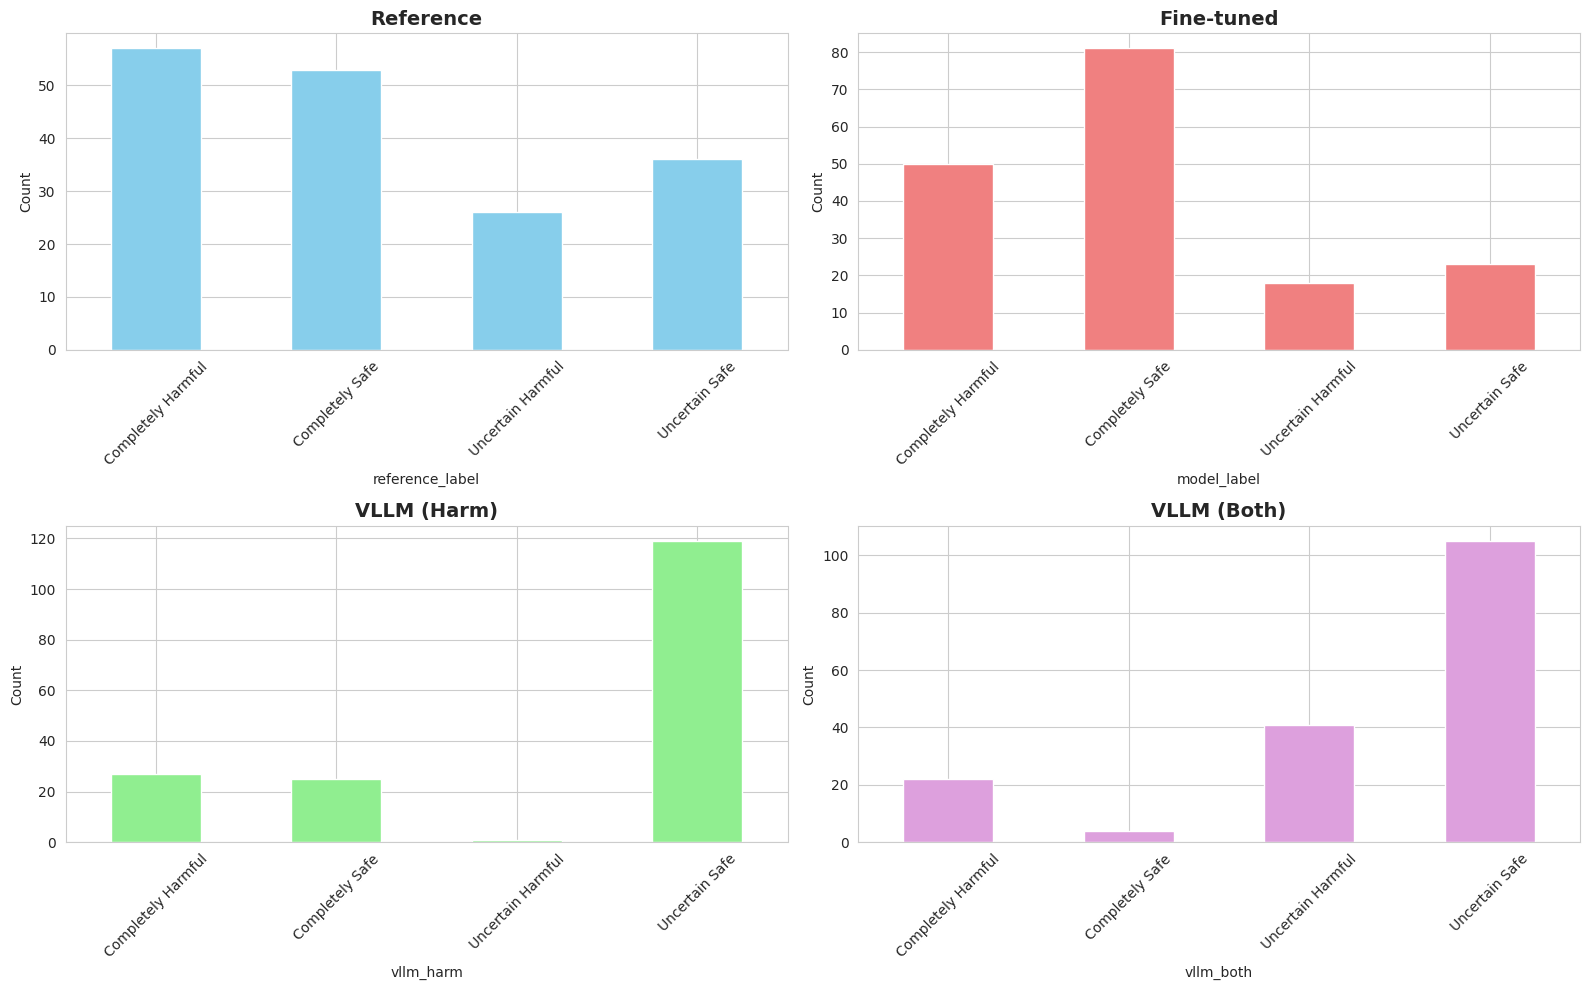

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Get sorted labels alphabetically
sorted_labels = sorted(df_clean['reference_label'].unique())

# Reference labels
ref_counts = df_clean['reference_label'].value_counts().reindex(sorted_labels, fill_value=0)
ref_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Reference', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Fine-tuned model labels
model_counts = df_clean['model_label'].value_counts().reindex(sorted_labels, fill_value=0)
model_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Fine-tuned', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# VLLM harm-only labels
vllm_harm_counts = df_clean['vllm_harm'].value_counts().reindex(sorted_labels, fill_value=0)
vllm_harm_counts.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('VLLM (Harm)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

# VLLM both labels
vllm_both_counts = df_clean['vllm_both'].value_counts().reindex(sorted_labels, fill_value=0)
vllm_both_counts.plot(kind='bar', ax=axes[3], color='plum')
axes[3].set_title('VLLM (Both)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Count')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Summary Metrics

In [10]:
# Calculate metrics for all models
model_acc = accuracy_score(df_clean['reference_label'], df_clean['model_label'])
vllm_harm_acc = accuracy_score(df_clean['reference_label'], df_clean['vllm_harm'])
vllm_both_acc = accuracy_score(df_clean['reference_label'], df_clean['vllm_both'])

model_f1 = f1_score(df_clean['reference_label'], df_clean['model_label'], average='macro', zero_division=0)
vllm_harm_f1 = f1_score(df_clean['reference_label'], df_clean['vllm_harm'], average='macro', zero_division=0)
vllm_both_f1 = f1_score(df_clean['reference_label'], df_clean['vllm_both'], average='macro', zero_division=0)

model_f1_weighted = f1_score(df_clean['reference_label'], df_clean['model_label'], average='weighted', zero_division=0)
vllm_harm_f1_weighted = f1_score(df_clean['reference_label'], df_clean['vllm_harm'], average='weighted', zero_division=0)
vllm_both_f1_weighted = f1_score(df_clean['reference_label'], df_clean['vllm_both'], average='weighted', zero_division=0)

# Agreement rates
model_vllm_harm_agreement = (df_clean['model_label'] == df_clean['vllm_harm']).sum() / len(df_clean)
model_vllm_both_agreement = (df_clean['model_label'] == df_clean['vllm_both']).sum() / len(df_clean)
vllm_harm_both_agreement = (df_clean['vllm_harm'] == df_clean['vllm_both']).sum() / len(df_clean)

summary_df = pd.DataFrame({
    'Model': ['Fine-tuned', 'VLLM (Harm)', 'VLLM (Both)'],
    'Accuracy': [model_acc, vllm_harm_acc, vllm_both_acc],
    'F1 (Macro)': [model_f1, vllm_harm_f1, vllm_both_f1],
    'F1 (Weighted)': [model_f1_weighted, vllm_harm_f1_weighted, vllm_both_f1_weighted]
})

print("Summary Metrics (vs Reference Labels)")
print("=" * 80)
display(summary_df)

Summary Metrics (vs Reference Labels)


,Model,Accuracy,F1 (Macro),F1 (Weighted)
0,Fine-tuned,0.395349,0.343955,0.373944
1,VLLM (Harm),0.261628,0.194260,0.209819
2,VLLM (Both),0.250000,0.220623,0.210782
